# 02 — Machine Learning Workflow

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 2 of 20**

Notebook 1 gave you the vocabulary. This notebook walks through **every stage a real ML project passes
through**, in order, and — to keep it grounded rather than abstract — maps each stage onto the
**California Housing capstone project** you already built, so you can see what each stage looked like
in practice, not just in theory.


## 1. Problem Definition & Business Understanding

Before any data is touched, you must answer:
- **What business decision will this model inform?** (Not "predict house prices" but "help buyers/
  sellers/agents estimate a fair price so they don't over/under-price a listing.")
- **What does success look like, in business terms — not just accuracy?** (e.g., "predictions within
  10% of actual sale price for 90% of listings" is a business-meaningful target; "R² = 0.81" alone is not.)
- **Is ML even the right tool?** (Revisit Notebook 1, Section 1 — "when should it not be used?")
- **What's the cost of a wrong prediction**, and in which direction is it worse to be wrong (under- vs
  over-estimating)?
- **How will the prediction actually be used** — a one-time report, a live API, a batch job?

*In your project:* the framing was "estimate median house value for a district given its
socio-economic and geographic attributes" — a regression problem, chosen because the target
(`median_house_value`) is a continuous number, not a category.


## 2. Data Collection

Gather the raw data needed to address the problem. Sources include internal databases, public
datasets, APIs, web scraping, sensors, or purchased data. Key questions:
- Does the data actually cover the population you'll predict on?
- Is there enough volume, and enough history/variety?
- Are there legal/privacy/licensing constraints?

*In your project:* the California Housing dataset (1990 census, aggregated per district) was already
provided/fetched via `sklearn.datasets.fetch_california_housing` — collection was a solved step, but in
a real job this is often the most time-consuming stage.


## 3. Data Understanding / Exploratory Data Analysis (EDA)

Before changing anything, *look* at the data: shapes, dtypes, missing values, distributions,
correlations, outliers, class balance (for classification). The goal is to build intuition and catch
problems (data entry errors, leakage, skew) before they silently corrupt a model.

Typical EDA actions: `.info()`, `.describe()`, histograms, scatter matrices, correlation heatmaps,
geographic plots (for spatial data like housing).

*In your project:* this was your Sprint 4 (dataset analysis) work — histograms of each feature,
checking for the `median_house_value` cap at $500,001, and the strong geographic clustering visible when
plotting latitude/longitude.


## 4. Data Preprocessing

Clean and standardize the data so an algorithm can actually consume it:
- Handle missing values (drop, impute with mean/median/most-frequent, or a model-based imputer).
- Handle outliers (cap, remove, or transform, depending on whether they're errors or real extreme cases).
- Encode categorical variables (one-hot encoding, ordinal encoding, target encoding).
- Scale/normalize numeric features (StandardScaler, MinMaxScaler) — required for distance-based and
  gradient-based algorithms (KNN, SVM, Linear/Logistic Regression, neural nets); not required for
  tree-based models (Decision Trees, Random Forest).

*In your project:* `total_bedrooms` had missing values (handled with `SimpleImputer`), `ocean_proximity`
was one-hot encoded, and numeric features were scaled with `StandardScaler` inside a `Pipeline`.


## 5. Feature Engineering & Feature Selection

**Feature engineering** creates new, more informative features from existing ones (e.g.,
`rooms_per_household = total_rooms / households`) — often more impactful on model performance than
switching algorithms. **Feature selection** removes redundant or unhelpful features (via correlation
analysis, feature importance from a trained model, or statistical tests) to reduce noise, overfitting
risk, and training time.

*In your project (Sprint 6):* you engineered `rooms_per_household`, `bedrooms_per_room`, and
`population_per_household` — all of which turned out to correlate with `median_house_value` more
strongly than the raw counts they were derived from.


## 6. Train/Test Split

Before selecting or training any model, set aside a **test set** that the model — and you — will not
look at again until final evaluation. This is what lets you honestly estimate how the model will
perform on genuinely new data. (Full treatment, including validation sets and cross-validation, is
**Notebook 3**.)

*In your project:* an 80/20 `train_test_split`, stratified by an income-category bin so the test set's
income distribution matched the full dataset's (plain random splitting can accidentally create a
test set that's skewed toward one income bracket, biasing the evaluation).


## 7. Model Selection

Choose one or more candidate algorithms appropriate to the problem type (regression here), the data
size, interpretability needs, and training-time budget. Best practice is to **try several models as a
baseline** before optimizing any one of them, rather than committing early.

*In your project:* Linear Regression (as an interpretable baseline), Decision Tree Regressor, and
Random Forest Regressor were compared.


## 8. Model Training

Fit each candidate model on the **training set**: the algorithm searches for parameter values (Notebook
1, Section 6) that minimize the chosen loss function on that data.

*In your project:* `.fit(X_train, y_train)` for each candidate, typically wrapped inside a `Pipeline`
so preprocessing (imputation, encoding, scaling) is applied consistently and without leaking test-set
information into training (more on leakage in Notebook 3).


## 9. Prediction

Use the trained model to generate outputs for new inputs — either the held-out test set (for
evaluation) or genuinely new production data (for real use).

*In your project:* `.predict(X_test)` to get predicted median house values for the districts in the
test set.


## 10. Evaluation

Score the predictions against the true values using metrics appropriate to the problem type:
- Regression: MAE, MSE, RMSE, R² (deep dive in Notebook 13).
- Classification: Accuracy, Precision, Recall, F1, ROC-AUC (deep dive in Notebook 14).

Crucially: evaluate on data the model did **not** train on, and interpret the number in business terms,
not just report it (Notebook 1's "interpret the result" step).

*In your project:* RMSE on the test set (e.g., "predictions are typically off by ~$50k") was the
headline metric, cross-checked against a naive baseline (always predicting the mean) to confirm the
model was actually adding value.


## 11. Hyperparameter Tuning

Systematically search over hyperparameter values (Notebook 1, Section 6) — via Grid Search or
Randomized Search, combined with cross-validation — to find the configuration that generalizes best,
rather than manually guessing values.

*In your project:* `GridSearchCV` over `RandomForestRegressor`'s `n_estimators` and `max_features`.


## 12. Final Model Selection

Compare the tuned candidates on validation performance (never on the test set — that would leak test
information into the selection decision) and pick the one that best balances accuracy, complexity,
training/inference cost, and interpretability for the business need defined in Step 1. Only **then** is
the test set touched, exactly once, to report the final, honest performance estimate.


## 13. Deployment

Put the trained model where it can actually be used: wrapped in an API, embedded in a batch pipeline, or
exported for another system to load (`joblib`/`pickle` for scikit-learn models). Deployment also
means deciding on retraining cadence, rollback plans, and how predictions reach the end user.


## 14. Monitoring (post-deployment)

A deployed model's performance can silently degrade over time as the real world drifts away from the
training data's distribution (**data drift** / **concept drift** — e.g., a housing model trained on
2020 prices degrading as the market shifts). Monitoring means tracking prediction distributions, input
distributions, and — where ground truth eventually becomes available — actual error rates, with alerts
and a retraining plan.


## 15. The Workflow Diagram


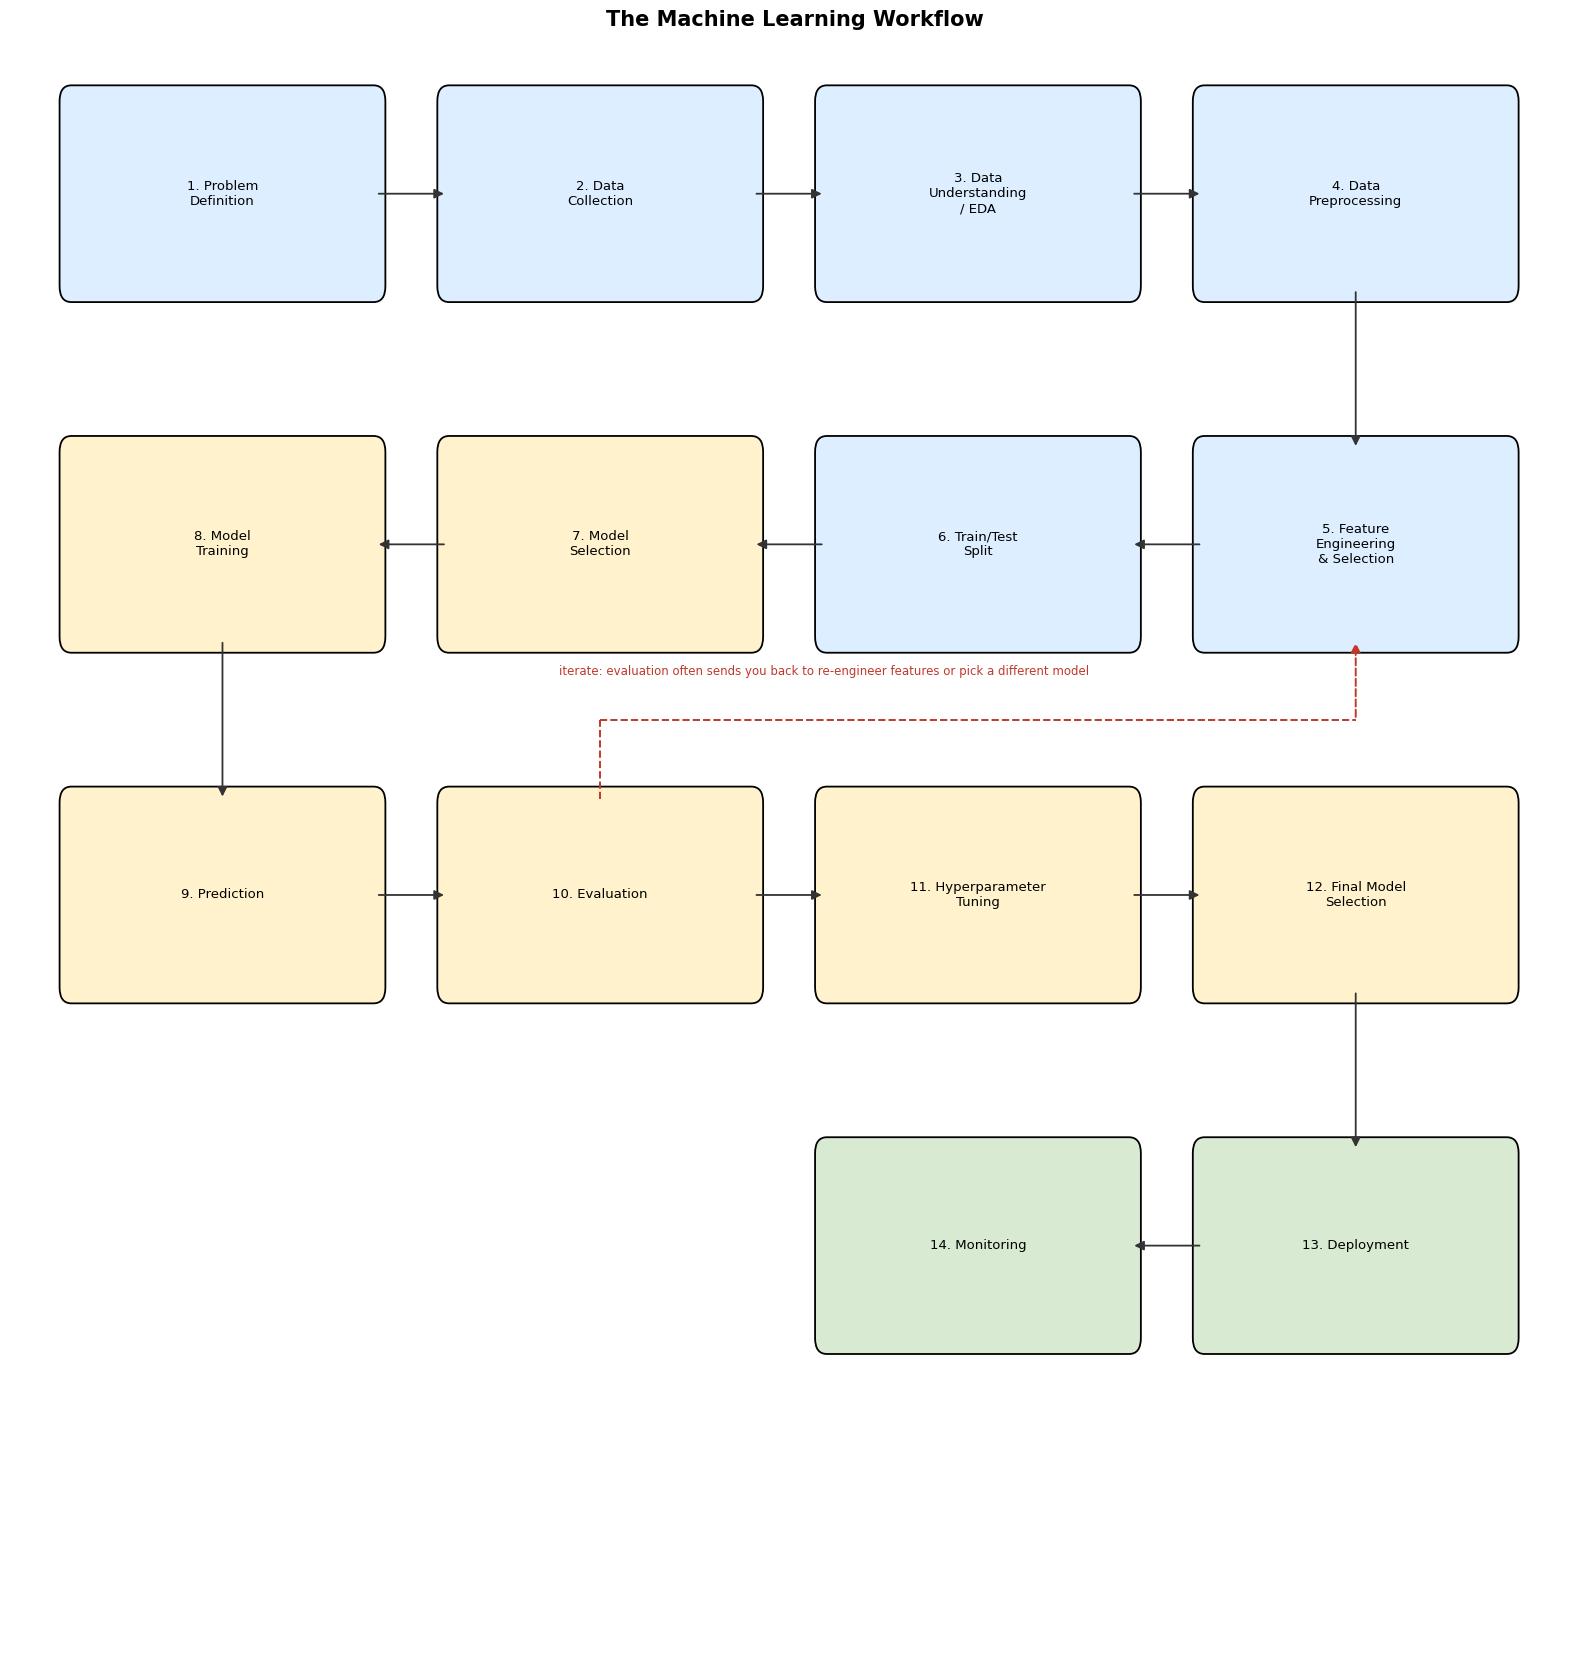

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [
    "1. Problem\nDefinition",
    "2. Data\nCollection",
    "3. Data\nUnderstanding\n/ EDA",
    "4. Data\nPreprocessing",
    "5. Feature\nEngineering\n& Selection",
    "6. Train/Test\nSplit",
    "7. Model\nSelection",
    "8. Model\nTraining",
    "9. Prediction",
    "10. Evaluation",
    "11. Hyperparameter\nTuning",
    "12. Final Model\nSelection",
    "13. Deployment",
    "14. Monitoring",
]

n = len(stages)
cols = 4
rows = (n + cols - 1) // cols
fig, ax = plt.subplots(figsize=(16, 4.2 * rows))

box_w, box_h = 2.6, 1.2
xgap, ygap = 0.6, 1.0

positions = {}
for i, label in enumerate(stages):
    row = i // cols
    col = i % cols
    # snake layout: alternate direction each row so arrows flow naturally left-right-left...
    if row % 2 == 1:
        col = cols - 1 - col
    x = col * (box_w + xgap)
    y = -row * (box_h + ygap)
    positions[i] = (x, y)
    color = "#dceeff" if i < 6 else ("#fff2cc" if i < 12 else "#d9ead3")
    box = FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.08,rounding_size=0.1",
                          linewidth=1.3, edgecolor="black", facecolor=color)
    ax.add_patch(box)
    ax.text(x + box_w / 2, y + box_h / 2, label, ha="center", va="center", fontsize=9.5)

# arrows connecting consecutive stages, following the snake path
for i in range(n - 1):
    x1, y1 = positions[i]
    x2, y2 = positions[i + 1]
    row1, row2 = i // cols, (i + 1) // cols
    if row1 == row2:
        if x2 > x1:
            start = (x1 + box_w, y1 + box_h / 2)
            end = (x2, y2 + box_h / 2)
        else:
            start = (x1, y1 + box_h / 2)
            end = (x2 + box_w, y2 + box_h / 2)
    else:
        # wrap to next row: arrow drops down from the last box in the row
        start = (x1 + box_w / 2, y1)
        end = (x2 + box_w / 2, y2 + box_h)
    arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14,
                             linewidth=1.3, color="#333333")
    ax.add_patch(arrow)

# feedback loop arrow: Evaluation (idx 9) back to Feature Engineering (idx 4)
# Routed entirely through the empty band between row 1 and row 2 so it never crosses a box.
x_eval, y_eval = positions[9]
x_fe, y_fe = positions[4]
band_y = y_eval + box_h + ygap / 2  # vertical midpoint of the empty gap between the two rows

loop_color = "#c0392b"
# 1) short vertical rise out of the Evaluation box, up into the band
ax.plot([x_eval + box_w / 2, x_eval + box_w / 2], [y_eval + box_h, band_y],
        linestyle="--", linewidth=1.4, color=loop_color)
# 2) horizontal run across the band (this is the segment that stays clear of every box)
ax.plot([x_eval + box_w / 2, x_fe + box_w / 2], [band_y, band_y],
        linestyle="--", linewidth=1.4, color=loop_color)
# 3) short vertical drop from the band into the Feature Engineering box, with the arrowhead
loop = FancyArrowPatch((x_fe + box_w / 2, band_y), (x_fe + box_w / 2, y_fe),
                        arrowstyle="-|>", mutation_scale=14, linewidth=1.4,
                        linestyle="--", color=loop_color)
ax.add_patch(loop)

ax.text((x_eval + x_fe) / 2, band_y + 0.28,
        "iterate: evaluation often sends you back to re-engineer features or pick a different model",
        fontsize=8.5, color=loop_color, ha="center")

ax.set_xlim(-0.5, cols * (box_w + xgap))
ax.set_ylim(-rows * (box_h + ygap) + 0.2, 1.6)
ax.axis("off")
ax.set_title("The Machine Learning Workflow", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("ml_workflow_diagram.png", dpi=130, bbox_inches="tight")
plt.show()


## 16. Summary — Key Takeaways

- The workflow is **iterative, not linear**: evaluation results routinely send you back to feature
  engineering, preprocessing, or model selection — the diagram's dashed arrow captures this.
- The **test set is touched exactly once**, at the very end, after all tuning decisions are locked in —
  touching it earlier (even "just to check") leaks information and inflates your confidence in the
  final number.
- Business framing (Step 1) and monitoring (Step 14) are often skipped by beginners but are exactly
  what separates a training exercise from a production ML system.
- Feature engineering typically moves the needle more than swapping algorithms — don't skip straight to
  "which model is best" without first asking "are these the right features?"


## 17. Try It Yourself (work through before Notebook 3)

1. Pick any one stage above (e.g., Data Preprocessing) and, for your MNIST classification project
   (Task 2), write 2-3 sentences describing what you actually did at that stage — this checks whether
   you can map the general workflow onto a *different* project than the housing one used above.
2. Draw (on paper or in a tool of your choice) your own version of the workflow diagram, but for a
   **classification** problem instead of regression — does anything in the stage descriptions change,
   or only the algorithms/metrics used within them?
3. Explain, in your own words, why touching the test set more than once (e.g., to "peek" and adjust
   hyperparameters) invalidates your final evaluation number. Where in the numbered stages above does
   the test set legitimately get used, and how many times?
